In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [9]:
order = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/orders_base.csv')
order['order_date'] = pd.to_datetime(order['order_date'])


In [10]:
order_items = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/order_items_base.csv')

C:\Users\hfake\AppData\Local\Temp\ipykernel_13240\1292588466.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/order_items_base.csv')


In [11]:
traffic = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/web_traffic_base.csv')
traffic['date'] = pd.to_datetime(traffic['date'])


In [12]:
sales = pd.read_csv('datathon_2026_round1/dataset/interim/csv_exports/sales_base.csv')
sales['date'] = pd.to_datetime(sales['date'])


In [14]:
order

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign
...,...,...,...,...,...,...,...,...
646940,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign
646941,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral
646942,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign
646943,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct


In [15]:
order_items

,order_id,product_id,quantity,discount_amount,promo_id,promo_id_2,unit_price
0,1,2400,7,0.0,NaN,NaN,1138.22
1,2,609,7,0.0,NaN,NaN,10166.25
2,3,396,3,0.0,NaN,NaN,11220.33
3,4,635,5,0.0,NaN,NaN,10639.25
4,6,1935,1,0.0,NaN,NaN,1597.84
...,...,...,...,...,...,...,...
714648,834372,690,8,0.0,NaN,NaN,4473.92
714649,834377,1995,7,0.0,NaN,NaN,5250.79
714650,834387,2331,8,0.0,NaN,NaN,7389.06
714651,834392,1115,5,0.0,NaN,NaN,4767.33


In [16]:
traffic

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral
...,...,...,...,...,...,...,...
3647,2022-12-27,17416,13150,62527,0.00506,252.4,organic_search
3648,2022-12-28,21071,15979,67456,0.00560,177.3,organic_search
3649,2022-12-29,20884,14640,82155,0.00522,165.6,direct
3650,2022-12-30,17679,13713,79308,0.00350,183.8,email_campaign


In [17]:
sales

,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79
...,...,...,...
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15


In [18]:
order_merge = order.merge(
    order_items,
    left_on='order_id',
    right_on='order_id',
    how='left'
)

In [19]:
order_merge

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,discount_amount,promo_id,promo_id_2,unit_price
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2400,7,0.0,NaN,NaN,1138.22
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,609,7,0.0,NaN,NaN,10166.25
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,396,3,0.0,NaN,NaN,11220.33
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,635,5,0.0,NaN,NaN,10639.25
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,0.0,NaN,NaN,1597.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714648,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,690,8,0.0,NaN,NaN,4473.92
714649,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,1995,7,0.0,NaN,NaN,5250.79
714650,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,2331,8,0.0,NaN,NaN,7389.06
714651,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct,1115,5,0.0,NaN,NaN,4767.33


In [20]:
order_merge = (
    order_merge
    .groupby('order_date')
    .agg(
        Total_Orders=('order_id', 'nunique'),
        Total_Order_Items=('order_id', 'count')
    )
    .reset_index()
    .rename(columns={'order_date': 'date'})
)

In [21]:
order_merge

,date,Total_Orders,Total_Order_Items
0,2012-07-04,162,174
1,2012-07-05,97,103
2,2012-07-06,93,99
3,2012-07-07,73,75
4,2012-07-08,88,94
...,...,...,...
3828,2022-12-27,108,125
3829,2022-12-28,164,192
3830,2022-12-29,143,159
3831,2022-12-30,106,116


In [22]:
sessions_daily = (
    traffic
    .groupby('date')['sessions']
    .sum()
    .reset_index()
)

In [23]:
sessions_daily

,date,sessions
0,2013-01-01,9760
1,2013-01-02,10456
2,2013-01-03,10076
3,2013-01-04,9973
4,2013-01-05,10223
...,...,...
3647,2022-12-27,17416
3648,2022-12-28,21071
3649,2022-12-29,20884
3650,2022-12-30,17679


In [24]:
sessions_daily_sales = sales.merge(
    sessions_daily,
    left_on='date',
    right_on='date',
    how='left'
)

In [25]:
sessions_daily_sales

,date,revenue,cogs,sessions
0,2012-07-04,5123547.94,3982991.19,NaN
1,2012-07-05,2751773.45,2150580.23,NaN
2,2012-07-06,3054029.42,2517632.84,NaN
3,2012-07-07,2667930.94,2108246.62,NaN
4,2012-07-08,2360851.90,1808622.79,NaN
...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,17416.0
3829,2022-12-28,3448729.20,3513621.00,21071.0
3830,2022-12-29,3083944.33,3170787.10,20884.0
3831,2022-12-30,2884668.76,3022292.15,17679.0


In [27]:
overview = sessions_daily_sales.merge(
    order_merge,
    left_on='date',
    right_on='date',
    how='left'
) 

In [28]:
overview

,date,revenue,cogs,sessions,Total_Orders,Total_Order_Items
0,2012-07-04,5123547.94,3982991.19,NaN,162,174
1,2012-07-05,2751773.45,2150580.23,NaN,97,103
2,2012-07-06,3054029.42,2517632.84,NaN,93,99
3,2012-07-07,2667930.94,2108246.62,NaN,73,75
4,2012-07-08,2360851.90,1808622.79,NaN,88,94
...,...,...,...,...,...,...
3828,2022-12-27,2100553.66,2184872.24,17416.0,108,125
3829,2022-12-28,3448729.20,3513621.00,21071.0,164,192
3830,2022-12-29,3083944.33,3170787.10,20884.0,143,159
3831,2022-12-30,2884668.76,3022292.15,17679.0,106,116


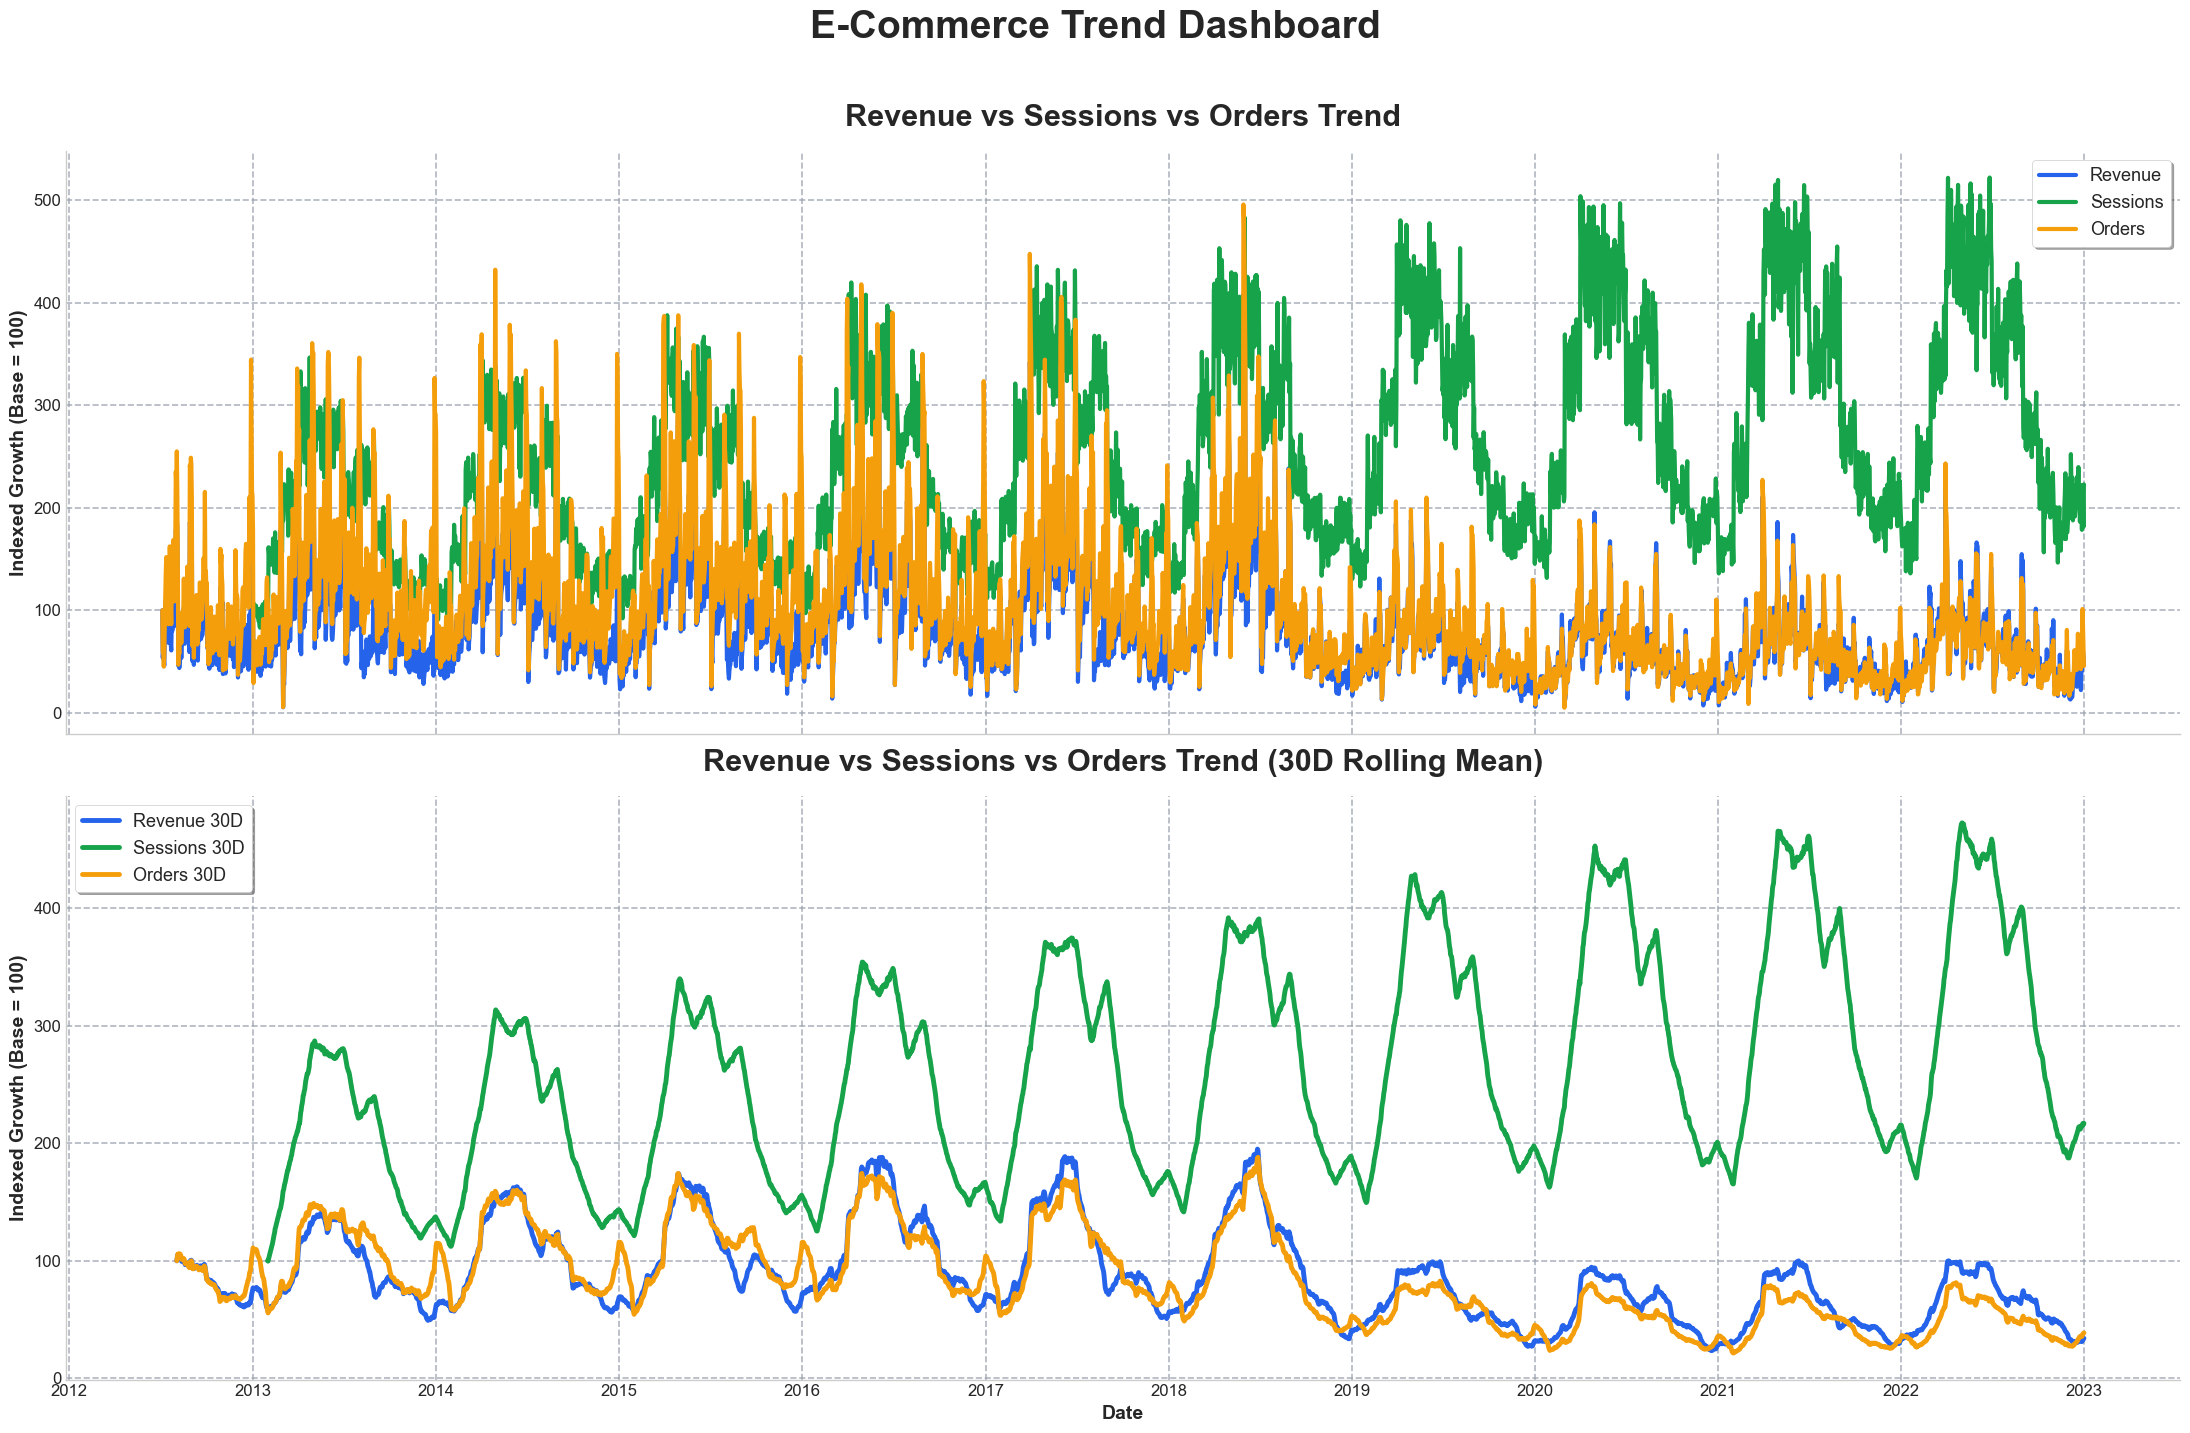

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

# =========================================================
# PREPARE DATA
# =========================================================

overview = overview.sort_values('date').copy()

overview['date'] = pd.to_datetime(
    overview['date'],
    errors='coerce'
)

# =========================================================
# ROLLING FEATURES
# =========================================================

overview['Revenue_30D'] = (
    overview['revenue']
    .rolling(30)
    .mean()
)

overview['Sessions_30D'] = (
    overview['sessions']
    .rolling(30)
    .mean()
)

overview['Orders_30D'] = (
    overview['Total_Orders']
    .rolling(30)
    .mean()
)

# =========================================================
# INDEX NORMALIZATION
# Giúp 3 biến khác scale có thể so sánh trend
# =========================================================

overview['Revenue_Index'] = (
    overview['revenue']
    / overview['revenue'].iloc[0]
) * 100

overview['Sessions_Index'] = (
    overview['sessions']
    / overview['sessions'].dropna().iloc[0]
) * 100

overview['Orders_Index'] = (
    overview['Total_Orders']
    / overview['Total_Orders'].iloc[0]
) * 100

# =========================================================
# ROLLING INDEX
# =========================================================

overview['Revenue_Index_30D'] = (
    overview['Revenue_30D']
    / overview['Revenue_30D'].dropna().iloc[0]
) * 100

overview['Sessions_Index_30D'] = (
    overview['Sessions_30D']
    / overview['Sessions_30D'].dropna().iloc[0]
) * 100

overview['Orders_Index_30D'] = (
    overview['Orders_30D']
    / overview['Orders_30D'].dropna().iloc[0]
) * 100

# =========================================================
# STYLE
# =========================================================

plt.style.use('seaborn-v0_8-whitegrid')

# =========================================================
# CREATE DASHBOARD
# =========================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(22,14),
    sharex=True
)

fig.patch.set_facecolor('white')

# =========================================================
# CHART 1
# ORIGINAL TREND
# =========================================================

axes[0].plot(
    overview['date'],
    overview['Revenue_Index'],
    linewidth=3,
    label='Revenue',
    color='#2563eb'
)

axes[0].plot(
    overview['date'],
    overview['Sessions_Index'],
    linewidth=3,
    label='Sessions',
    color='#16a34a'
)

axes[0].plot(
    overview['date'],
    overview['Orders_Index'],
    linewidth=3,
    label='Orders',
    color='#f59e0b'
)

axes[0].set_title(
    'Revenue vs Sessions vs Orders Trend',
    fontsize=22,
    fontweight='bold',
    pad=18
)

axes[0].set_ylabel(
    'Indexed Growth (Base = 100)',
    fontsize=14,
    fontweight='bold'
)

axes[0].legend(
    fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True
)

axes[0].set_axisbelow(True)

axes[0].grid(
    True,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8,
    color='#9ca3af'
)

# =========================================================
# CHART 2
# ROLLING 30D TREND
# =========================================================

axes[1].plot(
    overview['date'],
    overview['Revenue_Index_30D'],
    linewidth=3.5,
    label='Revenue 30D',
    color='#2563eb'
)

axes[1].plot(
    overview['date'],
    overview['Sessions_Index_30D'],
    linewidth=3.5,
    label='Sessions 30D',
    color='#16a34a'
)

axes[1].plot(
    overview['date'],
    overview['Orders_Index_30D'],
    linewidth=3.5,
    label='Orders 30D',
    color='#f59e0b'
)

axes[1].set_title(
    'Revenue vs Sessions vs Orders Trend (30D Rolling Mean)',
    fontsize=22,
    fontweight='bold',
    pad=18
)

axes[1].set_xlabel(
    'Date',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_ylabel(
    'Indexed Growth (Base = 100)',
    fontsize=14,
    fontweight='bold'
)

axes[1].legend(
    fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True
)

axes[1].set_axisbelow(True)

axes[1].grid(
    True,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8,
    color='#9ca3af'
)

# =========================================================
# AXIS STYLE
# =========================================================

for ax in axes:

    ax.tick_params(
        axis='x',
        labelsize=12
    )

    ax.tick_params(
        axis='y',
        labelsize=12
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# =========================================================
# DATE FORMAT
# =========================================================

axes[1].xaxis.set_major_locator(
    mdates.YearLocator()
)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

# =========================================================
# OVERALL TITLE
# =========================================================

fig.suptitle(
    'E-Commerce Trend Dashboard',
    fontsize=28,
    fontweight='bold',
    y=1.02
)

# =========================================================
# LAYOUT
# =========================================================

plt.subplots_adjust(
    hspace=0.35
)

plt.tight_layout()

# =========================================================
# SAVE
# =========================================================

plt.savefig(
    'overview_3line_chart.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

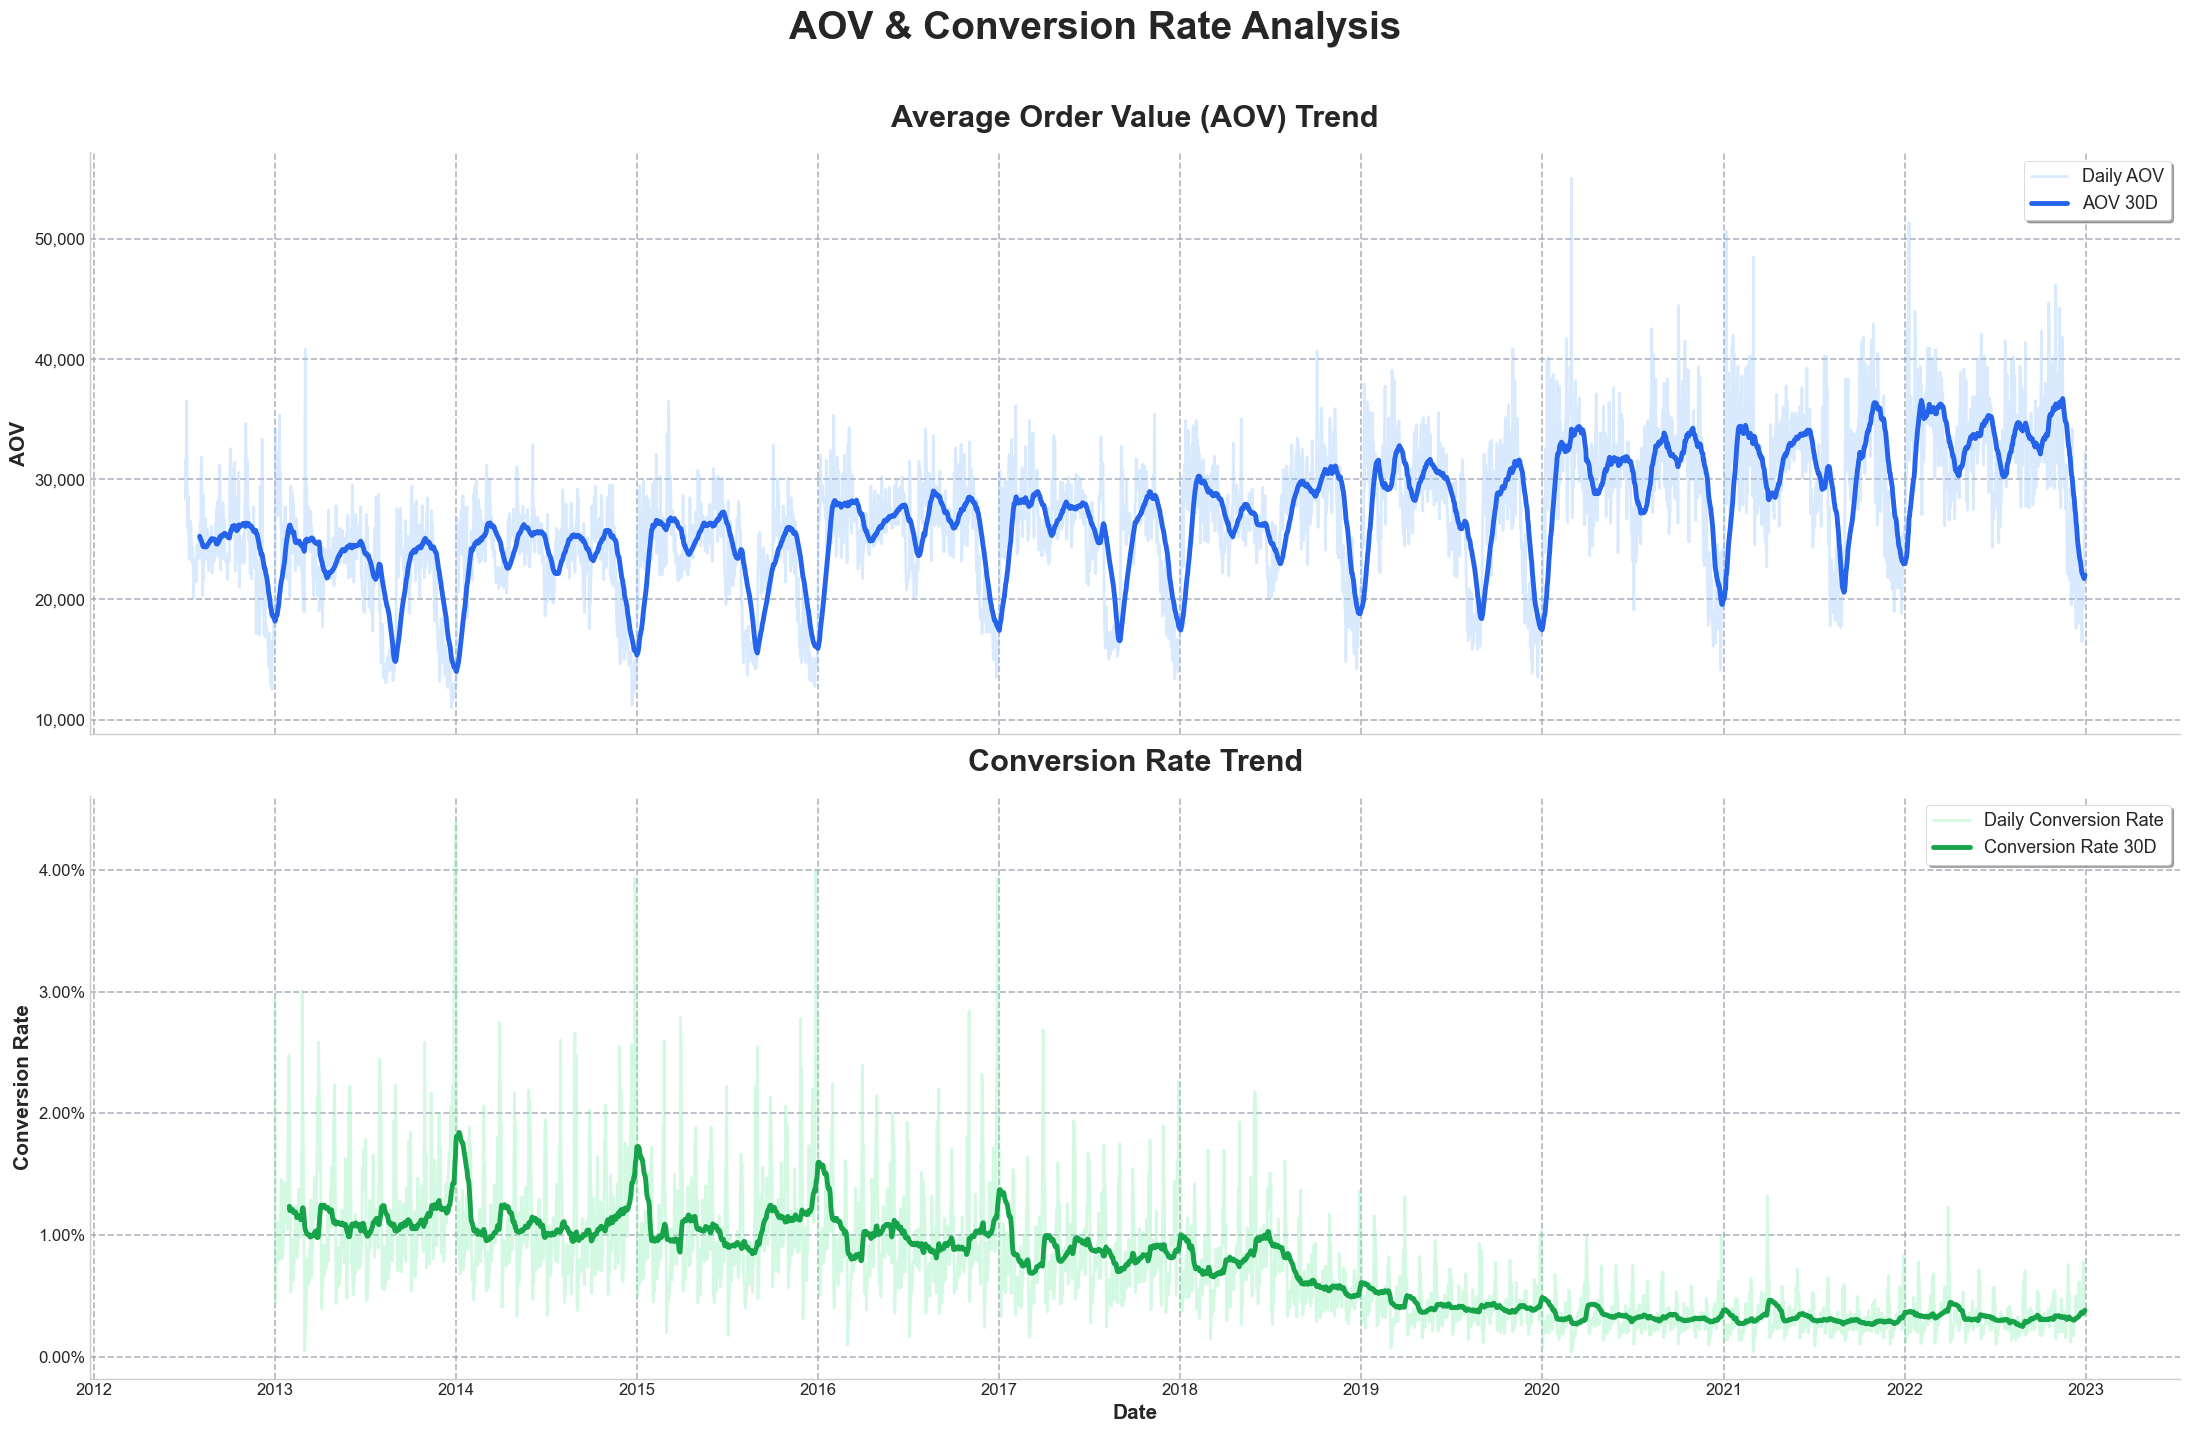

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

# =========================================================
# PREPARE DATA
# =========================================================

overview = overview.sort_values('date').copy()

overview['date'] = pd.to_datetime(
    overview['date'],
    errors='coerce'
)

# =========================================================
# CREATE BUSINESS METRICS
# =========================================================

overview['AOV'] = (
    overview['revenue']
    / overview['Total_Orders']
)

overview['Conversion_Rate'] = (
    overview['Total_Orders']
    / overview['sessions']
)

# =========================================================
# ROLLING MEAN 30D
# =========================================================

overview['AOV_30D'] = (
    overview['AOV']
    .rolling(30)
    .mean()
)

overview['Conversion_Rate_30D'] = (
    overview['Conversion_Rate']
    .rolling(30)
    .mean()
)

# =========================================================
# STYLE
# =========================================================

plt.style.use('seaborn-v0_8-whitegrid')

# =========================================================
# CREATE DASHBOARD
# =========================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(22,14),
    sharex=True
)

fig.patch.set_facecolor('white')

# =========================================================
# FORMATTERS
# =========================================================

money_formatter = ticker.FuncFormatter(
    lambda x, pos: f'{x:,.0f}'
)

percent_formatter = ticker.FuncFormatter(
    lambda x, pos: f'{x:.2%}'
)

# =========================================================
# CHART 1
# AOV
# =========================================================

axes[0].plot(
    overview['date'],
    overview['AOV'],
    linewidth=2,
    alpha=0.35,
    label='Daily AOV',
    color='#60a5fa'
)

axes[0].plot(
    overview['date'],
    overview['AOV_30D'],
    linewidth=3.5,
    label='AOV 30D',
    color='#2563eb'
)

axes[0].set_title(
    'Average Order Value (AOV) Trend',
    fontsize=22,
    fontweight='bold',
    pad=18
)

axes[0].set_ylabel(
    'AOV',
    fontsize=15,
    fontweight='bold'
)

axes[0].yaxis.set_major_formatter(
    money_formatter
)

axes[0].legend(
    fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True
)

axes[0].set_axisbelow(True)

axes[0].grid(
    True,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8,
    color='#9ca3af'
)

# =========================================================
# CHART 2
# CONVERSION RATE
# =========================================================

axes[1].plot(
    overview['date'],
    overview['Conversion_Rate'],
    linewidth=2,
    alpha=0.35,
    label='Daily Conversion Rate',
    color='#86efac'
)

axes[1].plot(
    overview['date'],
    overview['Conversion_Rate_30D'],
    linewidth=3.5,
    label='Conversion Rate 30D',
    color='#16a34a'
)

axes[1].set_title(
    'Conversion Rate Trend',
    fontsize=22,
    fontweight='bold',
    pad=18
)

axes[1].set_ylabel(
    'Conversion Rate',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel(
    'Date',
    fontsize=15,
    fontweight='bold'
)

axes[1].yaxis.set_major_formatter(
    percent_formatter
)

axes[1].legend(
    fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True
)

axes[1].set_axisbelow(True)

axes[1].grid(
    True,
    linestyle='--',
    linewidth=1.2,
    alpha=0.8,
    color='#9ca3af'
)

# =========================================================
# AXIS FORMATTING
# =========================================================

for ax in axes:

    ax.tick_params(
        axis='x',
        labelsize=12
    )

    ax.tick_params(
        axis='y',
        labelsize=12
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# =========================================================
# X-AXIS DATE FORMAT
# =========================================================

axes[1].xaxis.set_major_locator(
    mdates.YearLocator()
)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

# =========================================================
# OVERALL TITLE
# =========================================================

fig.suptitle(
    'AOV & Conversion Rate Analysis',
    fontsize=28,
    fontweight='bold',
    y=1.02
)

# =========================================================
# LAYOUT
# =========================================================

plt.subplots_adjust(
    hspace=0.38
)

plt.tight_layout()

# =========================================================
# SAVE
# =========================================================

plt.savefig(
    'aov_conversion_separate_charts.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()